In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
buildings = pd.read_csv('datasource-Geoscape-UoM_AURIN_DB_geoscape_melbourne_buildings_jun22.csv')
buildings.head()

,FID,ogc_fid,bld_pid,dt_create,dt_mod,capt_date,bld_rv_dt,bld_src,qual_class,loc_pid,...,num_vert,area,volume,bld_gm_qlt,cntrd_long,cntrd_lat,est_lev,roof_shape,tree_overh,wkb_geometry
0,geoscape_melbourne_buildings_jun22.2458729,2458729,bld144d516c16af,2022-03-11,NaN,2021-04-04,2021-04-04,7.5cm aerial,Urban,loc9901d119afda,...,7,186.28,2362.87,NaN,144.96984,-37.80846,4,Flat,No,POLYGON ((-37.808496369000004 144.969953743000...
1,geoscape_melbourne_buildings_jun22.2458763,2458763,bld801cf07d1aed,2022-03-11,NaN,2021-04-04,2021-04-04,7.5cm aerial,Urban,loc9901d119afda,...,5,61.80,1269.99,NaN,144.97193,-37.81062,6,Hipped,No,"POLYGON ((-37.810599278000005 144.972021844, -..."
2,geoscape_melbourne_buildings_jun22.2458894,2458894,blde9267a4026c2,2022-03-11,NaN,2021-04-04,2021-04-04,7.5cm aerial,Urban,loc9901d119afda,...,8,68.22,2642.44,NaN,144.97155,-37.81095,13,Flat,No,"POLYGON ((-37.810994667 144.97149376000002, -3..."
3,geoscape_melbourne_buildings_jun22.2458967,2458967,bld5b2ecad3aa9b,2022-03-11,NaN,2021-04-04,2021-04-04,7.5cm aerial,Urban,loc9901d119afda,...,4,12.07,376.45,NaN,144.97091,-37.81003,10,Flat,No,"POLYGON ((-37.810040077000004 144.970942482, -..."
4,geoscape_melbourne_buildings_jun22.2459001,2459001,bld4047ca627c0d,2022-03-11,NaN,2021-04-04,2021-04-04,7.5cm aerial,Urban,loc9901d119afda,...,4,346.75,10510.17,NaN,144.97235,-37.81084,10,Flat,No,"POLYGON ((-37.81087569 144.972498741, -37.8109..."


In [3]:
buildings.info()

<class 'pandas.DataFrame'>
RangeIndex: 2419 entries, 0 to 2418
Data columns (total 35 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   FID           2419 non-null   str    
 1   ogc_fid       2419 non-null   int64  
 2   bld_pid       2419 non-null   str    
 3   dt_create     2419 non-null   str    
 4   dt_mod        411 non-null    str    
 5   capt_date     2419 non-null   str    
 6   bld_rv_dt     2419 non-null   str    
 7   bld_src       2419 non-null   str    
 8   qual_class    2419 non-null   str    
 9   loc_pid       2419 non-null   str    
 10  state         2419 non-null   str    
 11  add_count     2419 non-null   int64  
 12  sp_adj        2419 non-null   str    
 13  sp_rv_dt      2419 non-null   str    
 14  solar_p       2419 non-null   str    
 15  solp_rv_dt    2419 non-null   str    
 16  plan_zone     2367 non-null   str    
 17  roof_hgt      2419 non-null   float64
 18  eave_hgt      2419 non-null   float64
 

In [4]:
buildings.columns

Index(['FID', 'ogc_fid', 'bld_pid', 'dt_create', 'dt_mod', 'capt_date',
       'bld_rv_dt', 'bld_src', 'qual_class', 'loc_pid', 'state', 'add_count',
       'sp_adj', 'sp_rv_dt', 'solar_p', 'solp_rv_dt', 'plan_zone', 'roof_hgt',
       'eave_hgt', 'grd_elev', 'grd_el_src', 'pr_rf_mat', 'roof_type',
       'roof_clr', 'mb_code', 'num_vert', 'area', 'volume', 'bld_gm_qlt',
       'cntrd_long', 'cntrd_lat', 'est_lev', 'roof_shape', 'tree_overh',
       'wkb_geometry'],
      dtype='str')

In [5]:
# Drop unnecessary ID and date columns
buildings.drop(['FID','ogc_fid','bld_pid','dt_create','dt_mod','capt_date','bld_rv_dt','sp_rv_dt','solp_rv_dt'],inplace=True,axis=1)

In [6]:
# Check value counts for categorical columns
categorical_cols = buildings.select_dtypes(include=['string']).columns

for col in categorical_cols:
    print(f"--- {col} ---")
    print(buildings[col].value_counts(dropna=False))
    print()

--- bld_src ---
bld_src
7.5cm aerial    2419
Name: count, dtype: int64

--- qual_class ---
qual_class
Urban    2419
Name: count, dtype: int64

--- loc_pid ---
loc_pid
loc9901d119afda    2419
Name: count, dtype: int64

--- state ---
state
VIC    2419
Name: count, dtype: int64

--- sp_adj ---
sp_adj
No     2401
Yes      18
Name: count, dtype: int64

--- solar_p ---
solar_p
No     2313
Yes     106
Name: count, dtype: int64

--- plan_zone ---
plan_zone
Special Use                2256
Residential                  60
NaN                          52
Community Use                44
Recreational/Open Space       7
Name: count, dtype: int64

--- grd_el_src ---
grd_el_src
5m    2419
Name: count, dtype: int64

--- pr_rf_mat ---
pr_rf_mat
Flat Concrete    2196
Metal             221
Tile                2
Name: count, dtype: int64

--- roof_type ---
roof_type
Moderate pitch or complexity      1083
Flat                              1054
Steep pitch or high complexity     282
Name: count, dtype: int64


In [7]:
# Drop unnecessary categorical columns that only have one value or mostly null values
buildings.drop(['bld_src','qual_class','loc_pid','state','grd_el_src','bld_gm_qlt'], inplace=True,axis=1)

In [8]:
buildings.info()

<class 'pandas.DataFrame'>
RangeIndex: 2419 entries, 0 to 2418
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   add_count     2419 non-null   int64  
 1   sp_adj        2419 non-null   str    
 2   solar_p       2419 non-null   str    
 3   plan_zone     2367 non-null   str    
 4   roof_hgt      2419 non-null   float64
 5   eave_hgt      2419 non-null   float64
 6   grd_elev      2419 non-null   float64
 7   pr_rf_mat     2419 non-null   str    
 8   roof_type     2419 non-null   str    
 9   roof_clr      2419 non-null   str    
 10  mb_code       2419 non-null   int64  
 11  num_vert      2419 non-null   int64  
 12  area          2419 non-null   float64
 13  volume        2419 non-null   float64
 14  cntrd_long    2419 non-null   float64
 15  cntrd_lat     2419 non-null   float64
 16  est_lev       2419 non-null   int64  
 17  roof_shape    2419 non-null   str    
 18  tree_overh    2419 non-null   str    
 

In [9]:
buildings.describe()

,add_count,roof_hgt,eave_hgt,grd_elev,mb_code,num_vert,area,volume,cntrd_long,cntrd_lat,est_lev
count,2419.000000,2419.000000,2419.000000,2419.000000,2.419000e+03,2419.000000,2419.000000,2419.000000,2419.000000,2419.000000,2419.000000
mean,96.529971,35.763134,35.175688,18.638871,2.050993e+10,13.987598,531.070500,21318.772968,144.963290,-37.812780,11.199669
std,319.498589,37.065323,37.161542,7.671003,1.305595e+08,31.095265,850.191064,51623.478456,0.005329,0.003232,12.546927
min,0.000000,1.520000,0.550000,0.080000,2.039286e+10,3.000000,8.190000,22.780000,144.951850,-37.821140,1.000000
25%,3.000000,14.500000,13.645000,13.245000,2.039392e+10,5.000000,77.530000,1405.495000,144.959020,-37.815040,4.000000
50%,9.000000,22.860000,22.170000,18.580000,2.039865e+10,8.000000,226.970000,4587.270000,144.963230,-37.812920,7.000000
75%,42.000000,41.115000,40.595000,24.355000,2.066437e+10,14.000000,664.440000,17589.100000,144.967575,-37.810330,13.000000
max,3494.000000,272.330000,272.330000,34.550000,2.066492e+10,768.000000,15232.440000,865412.840000,144.974130,-37.806070,90.000000


In [10]:
buildings.head()

,add_count,sp_adj,solar_p,plan_zone,roof_hgt,eave_hgt,grd_elev,pr_rf_mat,roof_type,roof_clr,mb_code,num_vert,area,volume,cntrd_long,cntrd_lat,est_lev,roof_shape,tree_overh,wkb_geometry
0,3,No,No,Special Use,12.68,12.68,28.51,Flat Concrete,Flat,#484745,20664610000,7,186.28,2362.87,144.96984,-37.80846,4,Flat,No,POLYGON ((-37.808496369000004 144.969953743000...
1,42,No,No,Special Use,20.55,18.85,30.62,Flat Concrete,Moderate pitch or complexity,#DCDCDC,20394000000,5,61.80,1269.99,144.97193,-37.81062,6,Hipped,No,"POLYGON ((-37.810599278000005 144.972021844, -..."
2,173,No,No,Special Use,39.05,39.05,28.98,Flat Concrete,Flat,#EEE8DA,20394010000,8,68.22,2642.44,144.97155,-37.81095,13,Flat,No,"POLYGON ((-37.810994667 144.97149376000002, -3..."
3,63,No,No,Special Use,31.20,31.20,27.85,Flat Concrete,Flat,#BAAE92,20394060000,4,12.07,376.45,144.97091,-37.81003,10,Flat,No,"POLYGON ((-37.810040077000004 144.970942482, -..."
4,3,No,No,Special Use,30.31,30.31,32.12,Flat Concrete,Flat,#D6D6CB,20394000000,4,346.75,10510.17,144.97235,-37.81084,10,Flat,No,"POLYGON ((-37.81087569 144.972498741, -37.8109..."


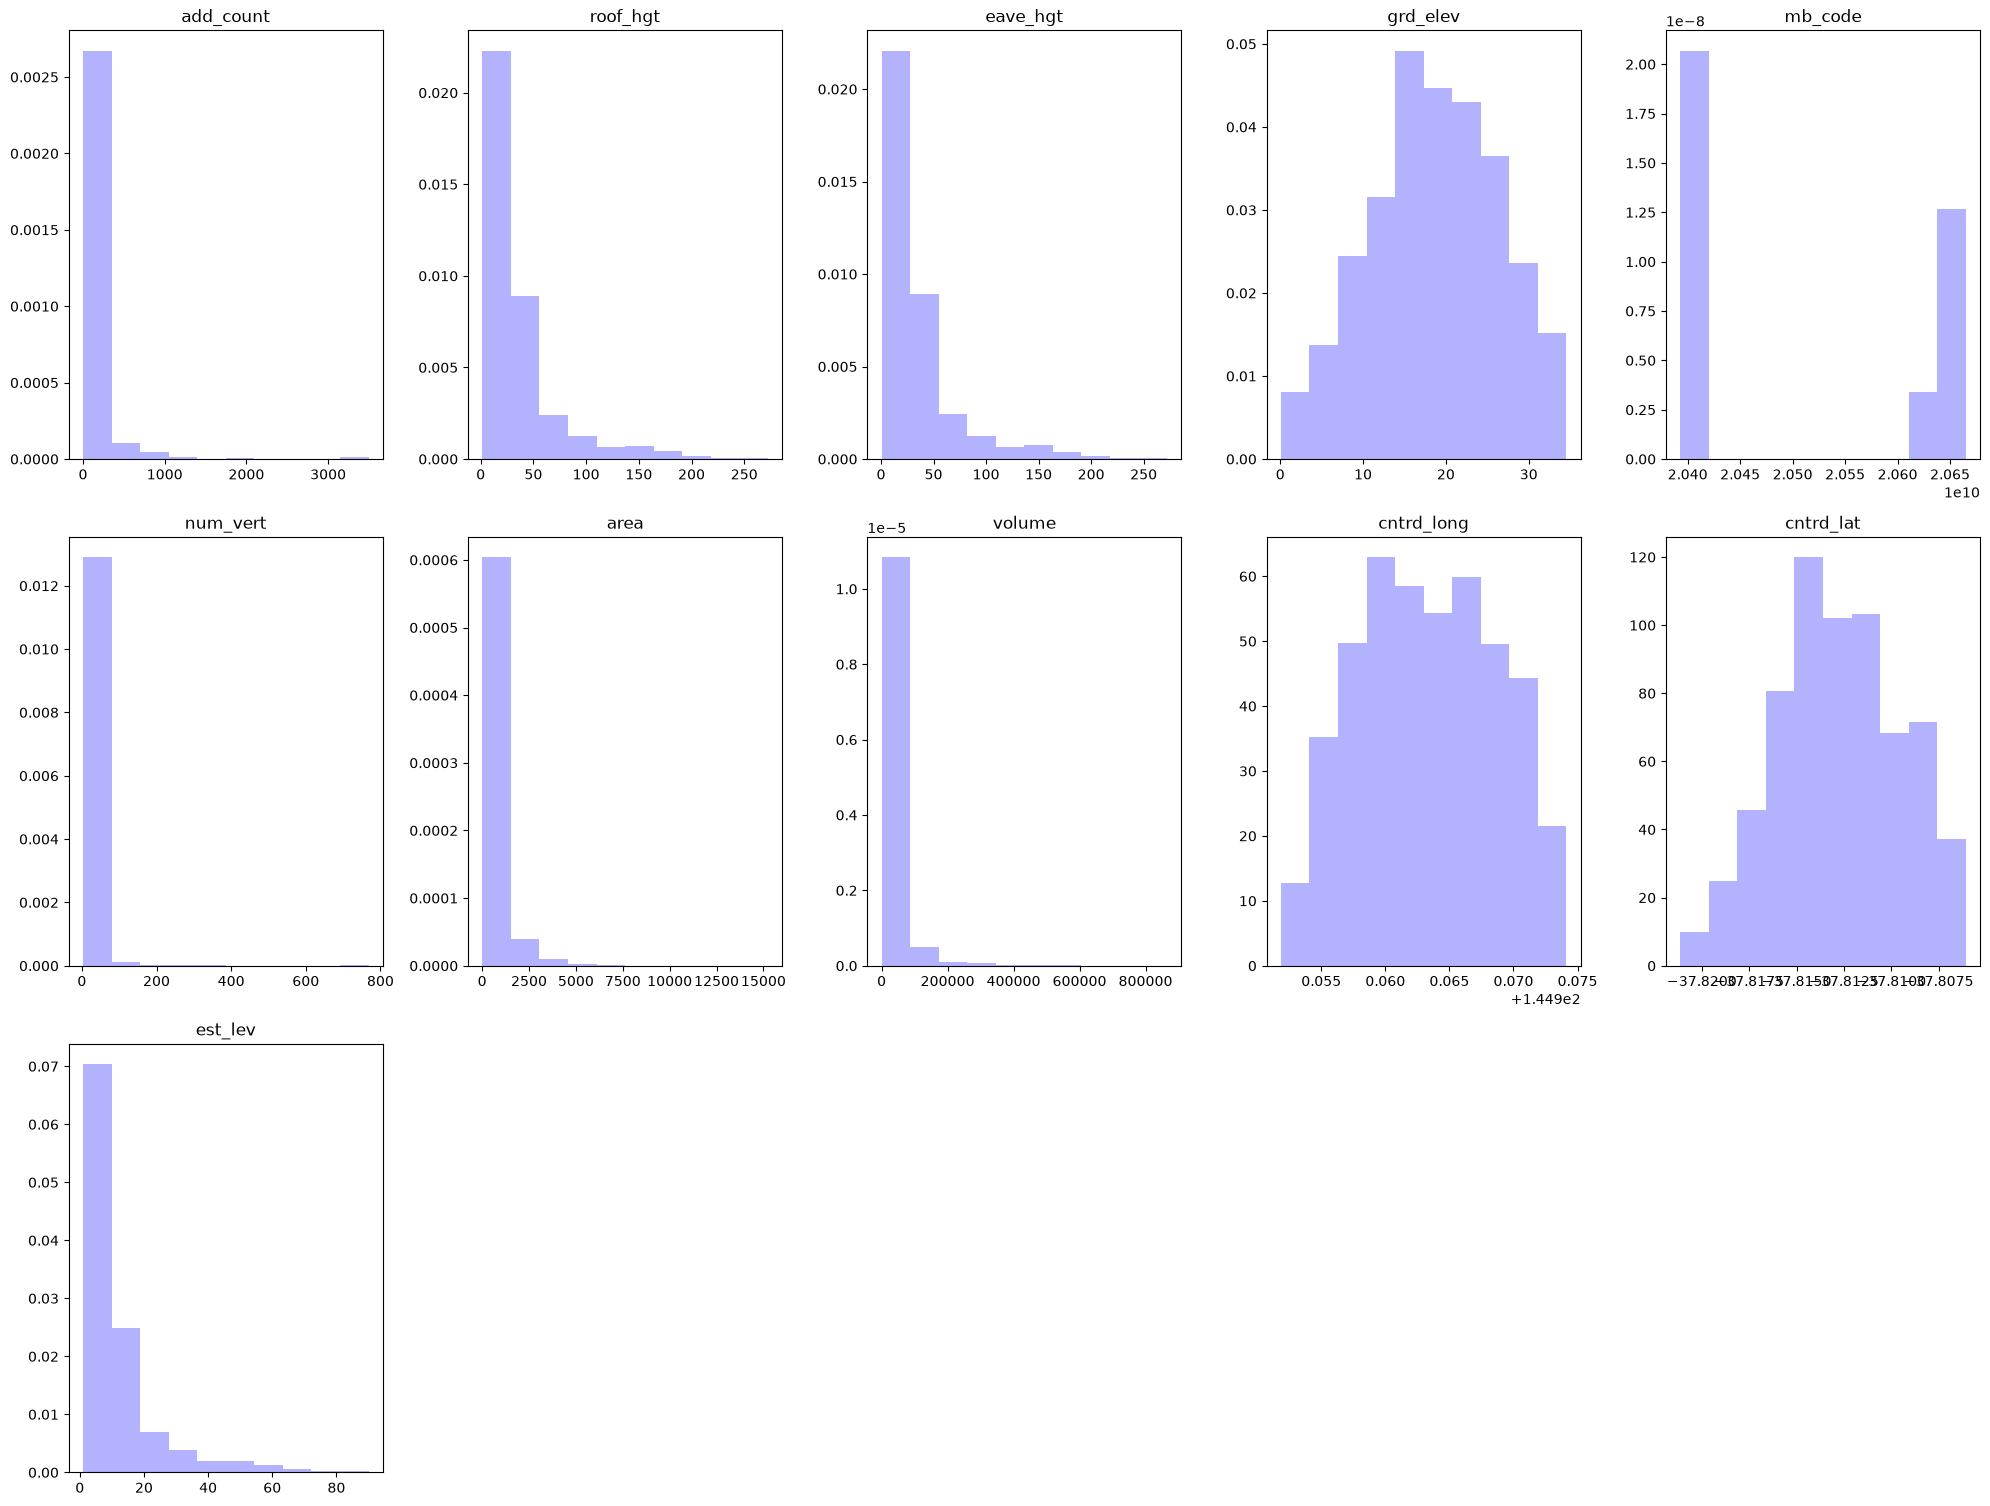

In [11]:
# Visualize the distribution of numerical columns
plt.figure(figsize=(20,20))
for i, col in enumerate(buildings.select_dtypes(include=['int64','float64']).columns):
    plt.subplot(4,5,i+1)
    plt.hist(buildings[col], alpha=0.3, color='b', density=True)
    plt.title(col)
    plt.xticks()
plt.tight_layout()
plt.show()

In [12]:
buildings.mb_code.value_counts(dropna=False)

mb_code
20393500000    70
20401330000    58
20398201000    42
20395891000    39
20393971000    36
               ..
20393724000     1
20394470000     1
20393725000     1
20394560000     1
20393670000     1
Name: count, Length: 260, dtype: int64

In [13]:
# Dropping mb_code as it identifies the mesh block the building primarily belongs to, ie. location, which is not relevant for the analysis
# Dropping grd_elev as it is the ground elevation of the building, which is not relevant for the analysis
# Dropping roof_clr for simplicity, too many unique values and not relevant for the analysis
buildings.drop(['mb_code','grd_elev','roof_clr'], inplace=True,axis=1)

In [14]:
# Fill missing values in plan_zone with 'Unknown' and check value counts
buildings['plan_zone'] = buildings['plan_zone'].fillna('Unknown')
buildings.plan_zone.value_counts(dropna=False)

plan_zone
Special Use                2256
Residential                  60
Unknown                      52
Community Use                44
Recreational/Open Space       7
Name: count, dtype: int64

In [24]:
# Hold out spatial columns for later use (mapping/visualization), not used in clustering
spatial_cols = buildings[['cntrd_long', 'cntrd_lat', 'wkb_geometry']].copy()
buildings.drop(['cntrd_long', 'cntrd_lat', 'wkb_geometry'], inplace=True, axis=1)
buildings.head()

,add_count,sp_adj,solar_p,plan_zone,roof_hgt,eave_hgt,pr_rf_mat,roof_type,num_vert,area,volume,est_lev,roof_shape,tree_overh
0,3,No,No,Special Use,12.68,12.68,Flat Concrete,Flat,7,186.28,2362.87,4,Flat,No
1,42,No,No,Special Use,20.55,18.85,Flat Concrete,Moderate pitch or complexity,5,61.80,1269.99,6,Hipped,No
2,173,No,No,Special Use,39.05,39.05,Flat Concrete,Flat,8,68.22,2642.44,13,Flat,No
3,63,No,No,Special Use,31.20,31.20,Flat Concrete,Flat,4,12.07,376.45,10,Flat,No
4,3,No,No,Special Use,30.31,30.31,Flat Concrete,Flat,4,346.75,10510.17,10,Flat,No


In [25]:
buildings.info()

<class 'pandas.DataFrame'>
RangeIndex: 2419 entries, 0 to 2418
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   add_count   2419 non-null   int64  
 1   sp_adj      2419 non-null   str    
 2   solar_p     2419 non-null   str    
 3   plan_zone   2419 non-null   str    
 4   roof_hgt    2419 non-null   float64
 5   eave_hgt    2419 non-null   float64
 6   pr_rf_mat   2419 non-null   str    
 7   roof_type   2419 non-null   str    
 8   num_vert    2419 non-null   int64  
 9   area        2419 non-null   float64
 10  volume      2419 non-null   float64
 11  est_lev     2419 non-null   int64  
 12  roof_shape  2419 non-null   str    
 13  tree_overh  2419 non-null   str    
dtypes: float64(4), int64(3), str(7)
memory usage: 264.7 KB


In [ ]:
# Convert data types of remaining columns to dictionary to specify categorical and numerical columns for clustering
buildings.dtypes.to_dict()

{'add_count': dtype('int64'),
 'sp_adj': <StringDtype(storage='python', na_value=nan)>,
 'solar_p': <StringDtype(storage='python', na_value=nan)>,
 'plan_zone': <StringDtype(storage='python', na_value=nan)>,
 'roof_hgt': dtype('float64'),
 'eave_hgt': dtype('float64'),
 'pr_rf_mat': <StringDtype(storage='python', na_value=nan)>,
 'roof_type': <StringDtype(storage='python', na_value=nan)>,
 'num_vert': dtype('int64'),
 'area': dtype('float64'),
 'volume': dtype('float64'),
 'est_lev': dtype('int64'),
 'roof_shape': <StringDtype(storage='python', na_value=nan)>,
 'tree_overh': <StringDtype(storage='python', na_value=nan)>}

In [ ]:
# Apply standard scaling to numerical columns for clustering
from sklearn.preprocessing import StandardScaler

numeric_cols = ['add_count', 'roof_hgt', 'eave_hgt', 'num_vert', 'area', 'volume', 'est_lev']
categorical_cols = ['sp_adj', 'solar_p', 'plan_zone', 'pr_rf_mat', 'roof_type', 'roof_shape', 'tree_overh']

buildings_scaled = buildings.copy()
scaler = StandardScaler()
buildings_scaled[numeric_cols] = scaler.fit_transform(buildings_scaled[numeric_cols])

buildings_scaled.head()

,add_count,sp_adj,solar_p,plan_zone,roof_hgt,eave_hgt,pr_rf_mat,roof_type,num_vert,area,volume,est_lev,roof_shape,tree_overh
0,-0.292800,No,No,Special Use,-0.622898,-0.605474,Flat Concrete,Flat,-0.224762,-0.405629,-0.367271,-0.573938,Flat,No
1,-0.170709,No,No,Special Use,-0.410526,-0.439408,Flat Concrete,Moderate pitch or complexity,-0.289094,-0.552073,-0.388446,-0.414503,Hipped,No
2,0.239393,No,No,Special Use,0.088696,0.104278,Flat Concrete,Flat,-0.192596,-0.544520,-0.361855,0.143517,Flat,No
3,-0.104967,No,No,Special Use,-0.123136,-0.107006,Flat Concrete,Flat,-0.321260,-0.610578,-0.405758,-0.095634,Flat,No
4,-0.292800,No,No,Special Use,-0.147153,-0.130961,Flat Concrete,Flat,-0.321260,-0.216844,-0.209417,-0.095634,Flat,No


In [40]:
from kmodes.kprototypes import KPrototypes

categorical_idx = [1, 2, 3, 6, 7, 12, 13]

matrix = buildings_scaled.to_numpy()

costs = []
k_range = range(2, 11)  # 2 to 10 inclusive

for k in k_range:
    kproto = KPrototypes(n_clusters=k, init='Cao', random_state=11)
    kproto.fit_predict(matrix, categorical=categorical_idx)
    costs.append(kproto.cost_)
    print(f"k={k}, cost={kproto.cost_:.2f}")

k=2, cost=12013.05
k=3, cost=10387.58
k=4, cost=9038.47
k=5, cost=8103.40
k=6, cost=6838.35
k=7, cost=6142.19
k=8, cost=5519.02
k=9, cost=5165.23
k=10, cost=4796.48


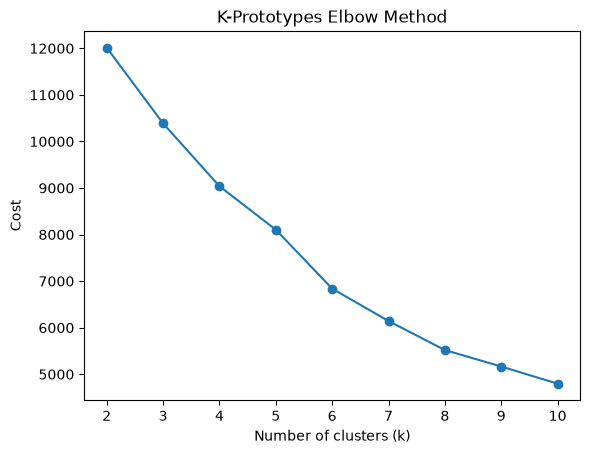

In [41]:
plt.plot(list(k_range), costs, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Cost')
plt.title('K-Prototypes Elbow Method')
plt.show()